In [1]:
import pandas as pd

trans = pd.read_csv("../data/raw/train_transaction.csv")
identity = pd.read_csv("../data/raw/train_identity.csv")

print(trans.shape, identity.shape)


(590540, 394) (144233, 41)


In [2]:
#Merge transaction + identity
df = trans.merge(identity, on="TransactionID", how="left")
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
#Understand Time - Convert to usable time
df["TransactionDT"] = pd.to_datetime(df["TransactionDT"], unit="s")
df = df.sort_values("TransactionDT")

In [4]:
#Create synthetic customer ID - enabling per-customer time-series modeling
df["customer_id"] = (
    df["card1"].astype(str) + "_" +
    df["card2"].astype(str)
)

<Axes: title={'center': 'Fraud Rate Over Time'}, xlabel='TransactionDT'>

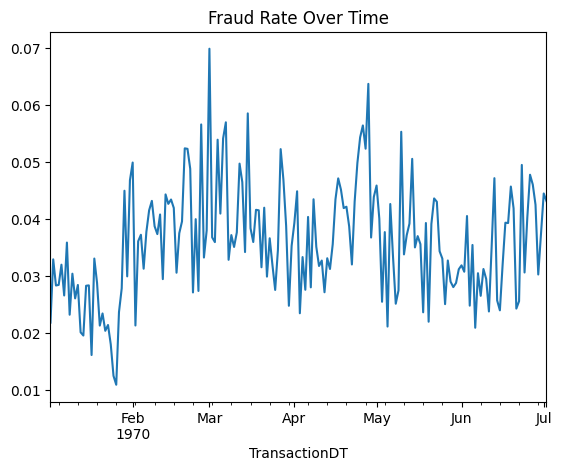

In [5]:
#First Fraud-over-Time Check
df.set_index("TransactionDT")["isFraud"].resample("D").mean().plot(
    title="Fraud Rate Over Time"
)

In [6]:
#Select Core Columns
core_cols = [
    "TransactionDT",
    "TransactionAmt",
    "customer_id",
    "card1",
    "card2",
    "ProductCD",
    "isFraud"
]

df_core = df[core_cols].dropna()
df_core.head()


,TransactionDT,TransactionAmt,customer_id,card1,card2,ProductCD,isFraud
1,1970-01-02 00:00:01,29.0,2755_404.0,2755,404.0,W,0
2,1970-01-02 00:01:09,59.0,4663_490.0,4663,490.0,W,0
3,1970-01-02 00:01:39,50.0,18132_567.0,18132,567.0,W,0
4,1970-01-02 00:01:46,50.0,4497_514.0,4497,514.0,H,0
5,1970-01-02 00:01:50,49.0,5937_555.0,5937,555.0,W,0


In [7]:
#Save Clean Base Dataset
df_core.to_csv("../data/processed/base_transactions.csv", index=False)